# Long-Term Trends in Melanoma Mortality in New Zealand Before and After the Introduction of Modern Systemic Therapies

## Research Question

Was the introduction of modern systemic therapies for melanoma in New Zealand during 2016 associated with a temporary or sustained change in melanoma mortality?

## Study Design

This study examines annual melanoma mortality in New Zealand from 1954 to 2023. The year 2016 is treated as a transition year because nivolumab and pembrolizumab received public funding during that year. The primary analysis compares mortality trends up to 2015 with trends from 2017 onwards.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Import and Initial Inspection

The mortality data were obtained from the Health New Zealand Cancer Web Tool. The dataset contains annual melanoma deaths and age-standardised mortality rates for all sexes, males, and females.

In [2]:
data_path = Path("NZ_Melanoma_Mortality_1954_2023_HealthNZ.xlsx")

mortality_df = pd.read_excel(
    data_path,
    sheet_name="Data"
)

print(f"Dataset shape: {mortality_df.shape}")
display(mortality_df.head())

Dataset shape: (210, 8)


,Year,Cancer,ICD code,Measure,Sex,Number of deaths,"Age-standardised mortality rate per 100,000",Data status
0,1954,Melanoma,C43,Deaths,All sex,38,1.9,Complete
1,1954,Melanoma,C43,Deaths,Male,21,2.2,Complete
2,1954,Melanoma,C43,Deaths,Female,17,1.7,Complete
3,1955,Melanoma,C43,Deaths,All sex,39,1.9,Complete
4,1955,Melanoma,C43,Deaths,Male,22,2.1,Complete


## 2. Data Quality Checks

The dataset was checked for missing values, duplicated year–sex records, year coverage, sex categories, and data status.

In [3]:
print(f"Year range: {mortality_df['Year'].min()}–{mortality_df['Year'].max()}")
print(f"Sex groups: {mortality_df['Sex'].unique().tolist()}")

print("\nMissing values:")
print(mortality_df.isna().sum())

duplicate_count = mortality_df.duplicated(
    subset=["Year", "Sex"]
).sum()

print(f"\nDuplicated year–sex records: {duplicate_count}")

print("\nData status:")
print(mortality_df["Data status"].value_counts())

Year range: 1954–2023
Sex groups: ['All sex', 'Male', 'Female']

Missing values:
Year                                           0
Cancer                                         0
ICD code                                       0
Measure                                        0
Sex                                            0
Number of deaths                               0
Age-standardised mortality rate per 100,000    0
Data status                                    0
dtype: int64

Duplicated year–sex records: 0

Data status:
Data status
Complete       204
Provisional      3
Preliminary      3
Name: count, dtype: int64


## 3. Data Preparation

Column names were standardised for analysis. Records were classified into the pre-introduction period (1954–2015), the 2016 transition year, and the post-introduction period (2017–2023).

In [4]:
column_mapping = {
    "Year": "year",
    "Cancer": "cancer",
    "ICD code": "icd_code",
    "Measure": "measure",
    "Sex": "sex",
    "Number of deaths": "deaths",
    "Age-standardised mortality rate per 100,000": "asr",
    "Data status": "data_status",
}

melanoma_df = mortality_df.rename(columns=column_mapping).copy()

melanoma_df["period"] = np.select(
    [
        melanoma_df["year"] <= 2015,
        melanoma_df["year"] == 2016,
        melanoma_df["year"] >= 2017,
    ],
    [
        "Pre-introduction",
        "Transition year",
        "Post-introduction",
    ],
    default="Unclassified",
)

melanoma_df = melanoma_df.sort_values(
    ["year", "sex"]
).reset_index(drop=True)

print("Updated columns:")
print(melanoma_df.columns.tolist())

print("\nRecords by study period:")
print(melanoma_df["period"].value_counts(sort=False))


Updated columns:
['year', 'cancer', 'icd_code', 'measure', 'sex', 'deaths', 'asr', 'data_status', 'period']

Records by study period:
period
Pre-introduction     186
Transition year        3
Post-introduction     21
Name: count, dtype: int64


## 4. Descriptive Comparison Around the 2016 Transition

Mortality was summarised across the late pre-introduction period, the 2016 transition year, the early post-introduction period, and the most recent post-introduction years.


In [5]:
recent_df = melanoma_df.loc[
    melanoma_df["year"] >= 2012
].copy()

recent_df["comparison_period"] = np.select(
    [
        recent_df["year"].between(2012, 2015),
        recent_df["year"] == 2016,
        recent_df["year"].between(2017, 2020),
        recent_df["year"].between(2021, 2023),
    ],
    [
        "Late pre-introduction (2012–2015)",
        "Transition year (2016)",
        "Early post-introduction (2017–2020)",
        "Recent post-introduction (2021–2023)",
    ],
    default="Unclassified",
)

period_order = [
    "Late pre-introduction (2012–2015)",
    "Transition year (2016)",
    "Early post-introduction (2017–2020)",
    "Recent post-introduction (2021–2023)",
]

recent_df["comparison_period"] = pd.Categorical(
    recent_df["comparison_period"],
    categories=period_order,
    ordered=True,
)

period_summary = (
    recent_df.groupby(
        ["sex", "comparison_period"],
        observed=True,
    )
    .agg(
        years=("year", "count"),
        mean_deaths=("deaths", "mean"),
        mean_asr=("asr", "mean"),
    )
    .reset_index()
)

baseline_asr = (
    period_summary.loc[
        period_summary["comparison_period"]
        == "Late pre-introduction (2012–2015)",
        ["sex", "mean_asr"],
    ]
    .rename(columns={"mean_asr": "baseline_asr"})
)

period_summary = period_summary.merge(
    baseline_asr,
    on="sex",
    how="left",
)

period_summary["asr_change_from_late_pre_pct"] = (
    (
        period_summary["mean_asr"]
        / period_summary["baseline_asr"]
        - 1
    )
    * 100
)

period_summary = period_summary.round(
    {
        "mean_deaths": 1,
        "mean_asr": 2,
        "baseline_asr": 2,
        "asr_change_from_late_pre_pct": 1,
    }
)

display(period_summary)

,sex,comparison_period,years,mean_deaths,mean_asr,baseline_asr,asr_change_from_late_pre_pct
0,All sex,Late pre-introduction (2012–2015),4,366.5,4.97,4.97,0.0
1,All sex,Transition year (2016),1,364.0,4.50,4.97,-9.5
2,All sex,Early post-introduction (2017–2020),4,307.2,3.48,4.97,-30.2
3,All sex,Recent post-introduction (2021–2023),3,328.3,3.37,4.97,-32.3
4,Female,Late pre-introduction (2012–2015),4,130.0,3.28,3.28,0.0
5,Female,Transition year (2016),1,121.0,2.90,3.28,-11.5
6,Female,Early post-introduction (2017–2020),4,105.0,2.20,3.28,-32.8
7,Female,Recent post-introduction (2021–2023),3,115.3,2.20,3.28,-32.8
8,Male,Late pre-introduction (2012–2015),4,236.5,6.95,6.95,0.0
9,Male,Transition year (2016),1,243.0,6.40,6.95,-7.9


### Initial Descriptive Findings

Compared with 2012–2015, the mean age-standardised melanoma mortality rate for all sexes was 30.2% lower during 2017–2020 and 32.3% lower during 2021–2023. Similar sustained reductions were observed among males and females.

Although the mean number of deaths increased slightly between the early and recent post-introduction periods, the age-standardised mortality rate remained stable. This difference may reflect population growth and population ageing, making the age-standardised rate the more appropriate measure for evaluating changes in mortality risk over time.

These descriptive findings indicate a sustained population-level reduction following the 2016 transition. However, they do not establish that modern systemic therapies caused the decline. Segmented regression and sensitivity analyses are required.

## 5. Long-Term Melanoma Mortality Trends

Annual age-standardised melanoma mortality rates were plotted from 1954 to 2023 for all sexes, males, and females. The shaded area represents the 2016 treatment-transition year.

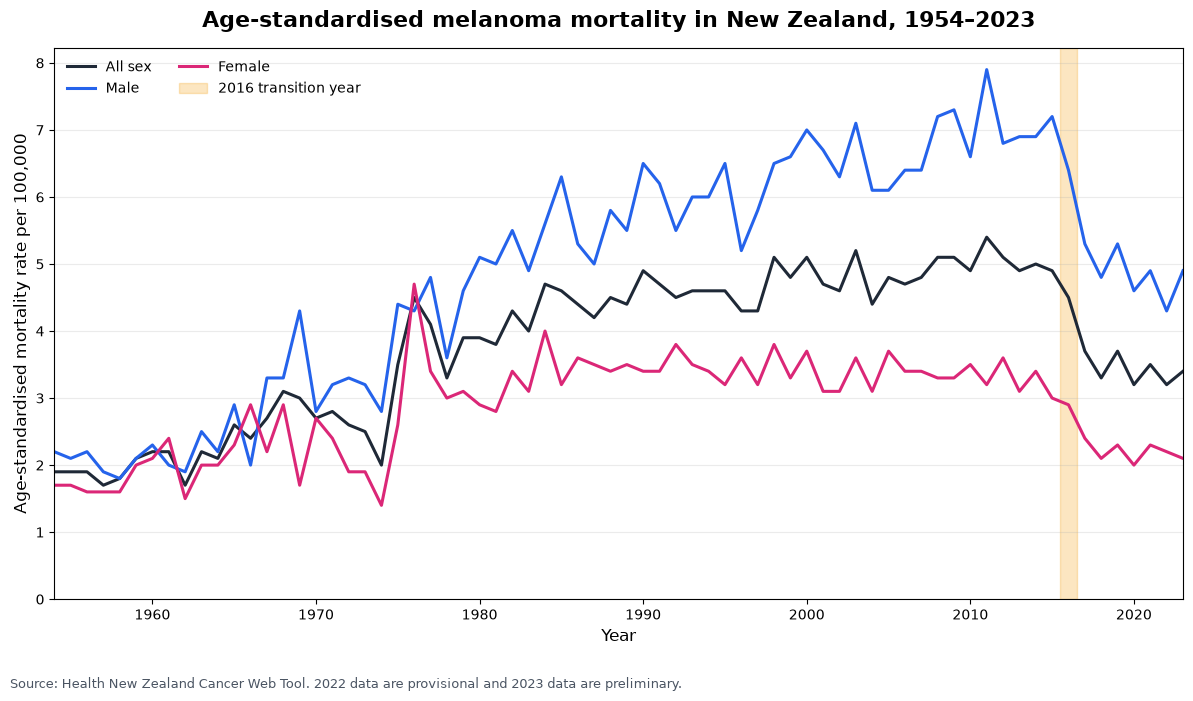

Figure saved: figures\Figure1_Long_Term_Melanoma_Mortality_by_Sex.png


In [6]:
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

sex_colours = {
    "All sex": "#1F2937",
    "Male": "#2563EB",
    "Female": "#DB2777",
}

fig, ax = plt.subplots(figsize=(12, 7))

for sex_group in ["All sex", "Male", "Female"]:
    sex_data = melanoma_df.loc[
        melanoma_df["sex"] == sex_group
    ]

    ax.plot(
        sex_data["year"],
        sex_data["asr"],
        label=sex_group,
        color=sex_colours[sex_group],
        linewidth=2.2,
    )

ax.axvspan(
    2015.5,
    2016.5,
    color="#F59E0B",
    alpha=0.25,
    label="2016 transition year",
)

ax.set_title(
    "Age-standardised melanoma mortality in New Zealand, 1954–2023",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel(
    "Age-standardised mortality rate per 100,000",
    fontsize=12,
)

ax.set_xlim(1954, 2023)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

fig.text(
    0.01,
    0.01,
    "Source: Health New Zealand Cancer Web Tool. "
    "2022 data are provisional and 2023 data are preliminary.",
    fontsize=9,
    color="#4B5563",
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

figure_path = figures_dir / (
    "Figure1_Long_Term_Melanoma_Mortality_by_Sex.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved: {figure_path}")

### Interpretation of Figure 1

Melanoma mortality increased over the earlier decades and remained consistently higher among males than females. Before 2016, the all-sex age-standardised mortality rate was generally between approximately 4.5 and 5.4 deaths per 100,000.

A marked decline occurred around the 2016 transition year across all three sex groups. Mortality rates remained below their pre-2016 levels through 2023, providing descriptive evidence of a sustained rather than temporary reduction. However, formal segmented regression is required to assess the magnitude and statistical significance of this change.

## 6. Mortality Trend Around the Introduction of Modern Therapies

The all-sex mortality trend from 2000 onwards was examined more closely around the 2016 transition.


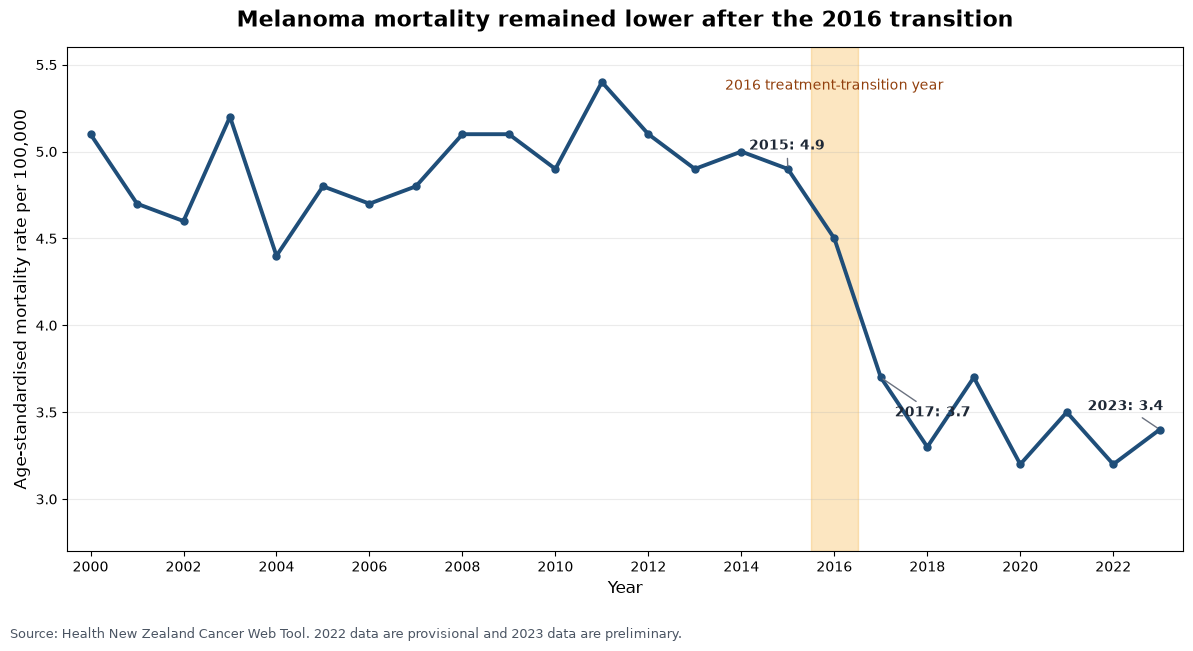

Figure saved: figures\Figure2_Melanoma_Mortality_Around_2016.png


In [7]:
all_sex_recent = melanoma_df.loc[
    (melanoma_df["sex"] == "All sex")
    & (melanoma_df["year"] >= 2000)
].copy()

fig, ax = plt.subplots(figsize=(12, 6.5))

ax.plot(
    all_sex_recent["year"],
    all_sex_recent["asr"],
    color="#1F4E79",
    linewidth=2.8,
    marker="o",
    markersize=5,
)

ax.axvspan(
    2015.5,
    2016.5,
    color="#F59E0B",
    alpha=0.25,
)

ax.text(
    2016,
    5.42,
    "2016 treatment-transition year",
    ha="center",
    va="top",
    fontsize=10,
    color="#92400E",
)

selected_years = {
    2015: (4.9, -28, 14),
    2017: (3.7, 10, -28),
    2023: (3.4, -52, 14),
}

for year, (rate, x_offset, y_offset) in selected_years.items():
    ax.annotate(
        f"{year}: {rate:.1f}",
        xy=(year, rate),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="#1F2937",
        arrowprops={
            "arrowstyle": "-",
            "color": "#6B7280",
        },
    )

ax.set_title(
    "Melanoma mortality remained lower after the 2016 transition",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel(
    "Age-standardised mortality rate per 100,000",
    fontsize=12,
)

ax.set_xlim(1999.5, 2023.5)
ax.set_ylim(2.7, 5.6)
ax.set_xticks(range(2000, 2024, 2))
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

fig.text(
    0.01,
    0.01,
    "Source: Health New Zealand Cancer Web Tool. "
    "2022 data are provisional and 2023 data are preliminary.",
    fontsize=9,
    color="#4B5563",
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

figure_path = figures_dir / (
    "Figure2_Melanoma_Mortality_Around_2016.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved: {figure_path}")

## 7. Primary Segmented Regression Analysis

A segmented ordinary least squares regression was fitted to the all-sex age-standardised mortality rate from 2000 to 2023. The year 2016 was excluded because it represented a transition year during which nivolumab and pembrolizumab became publicly funded.

The model estimated:

- the annual mortality trend before the introduction of modern therapies;
- the immediate level change in 2017;
- the change in annual trend after 2017.

Heteroskedasticity and autocorrelation-consistent standard errors with two lags were used.

In [8]:
model_df = melanoma_df.loc[
    (melanoma_df["sex"] == "All sex")
    & (melanoma_df["year"] >= 2000)
    & (melanoma_df["year"] != 2016)
].copy()

model_df["time"] = model_df["year"] - 2000
model_df["post_introduction"] = (
    model_df["year"] >= 2017
).astype(int)

model_df["time_after_introduction"] = np.where(
    model_df["year"] >= 2017,
    model_df["year"] - 2017,
    0,
)

predictors = [
    "time",
    "post_introduction",
    "time_after_introduction",
]

x_model = sm.add_constant(model_df[predictors])
y_model = model_df["asr"]

segmented_model = sm.OLS(
    y_model,
    x_model,
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 2},
)

confidence_intervals = segmented_model.conf_int()

model_results = pd.DataFrame(
    {
        "estimate": segmented_model.params,
        "standard_error": segmented_model.bse,
        "ci_lower": confidence_intervals[0],
        "ci_upper": confidence_intervals[1],
        "p_value": segmented_model.pvalues,
    }
).round(3)

post_slope_test = segmented_model.t_test(
    [0, 1, 0, 1]
)

post_slope = np.asarray(
    post_slope_test.effect
).item()

post_slope_p_value = np.asarray(
    post_slope_test.pvalue
).item()

durbin_watson = sm.stats.stattools.durbin_watson(
    segmented_model.resid
)

display(model_results)

print(f"Observations: {int(segmented_model.nobs)}")
print(f"R-squared: {segmented_model.rsquared:.3f}")
print(f"Adjusted R-squared: {segmented_model.rsquared_adj:.3f}")
print(f"Post-introduction annual slope: {post_slope:.3f}")
print(f"Post-introduction slope p-value: {post_slope_p_value:.3f}")
print(f"Durbin-Watson statistic: {durbin_watson:.3f}")

,estimate,standard_error,ci_lower,ci_upper,p_value
const,4.783,0.085,4.617,4.949,0.000
time,0.018,0.009,-0.000,0.036,0.051
post_introduction,-1.523,0.124,-1.765,-1.281,0.000
time_after_introduction,-0.065,0.015,-0.094,-0.035,0.000


Observations: 23
R-squared: 0.913
Adjusted R-squared: 0.899
Post-introduction annual slope: -0.046
Post-introduction slope p-value: 0.001
Durbin-Watson statistic: 2.626


### Interpretation of the Primary Model

Before the introduction of modern systemic therapies, the annual mortality trend was small and borderline statistically significant (0.018 deaths per 100,000 per year; p = 0.051).

At the beginning of the post-introduction period in 2017, the model estimated an immediate reduction of 1.523 deaths per 100,000 compared with the mortality rate expected from continuation of the pre-introduction trend (95% CI: −1.765 to −1.281; p < 0.001).

The annual trend also changed by −0.065 deaths per 100,000 following the transition (p < 0.001). The estimated post-introduction slope was −0.046 deaths per 100,000 per year (p = 0.001), indicating that the initial reduction was not followed by a return towards the previous mortality level.

The model explained 91.3% of the variation in mortality rates. These findings indicate a strong temporal association between the introduction of modern systemic therapies and a sustained reduction in melanoma mortality. They do not establish causality because other changes in prevention, diagnosis, population composition, and clinical care may also have contributed.

## 8. Sensitivity Analysis for Delayed Mortality Effects

The effect of newly funded therapies may not appear immediately in population mortality data. Therefore, the segmented regression was repeated with the post-introduction period beginning in 2017, 2018, and 2019. Years between 2016 and the selected post-period were treated as transition years and excluded.

In [9]:
def fit_lag_model(post_start_year):
    lag_df = melanoma_df.loc[
        (melanoma_df["sex"] == "All sex")
        & (melanoma_df["year"] >= 2000)
        & (
            (melanoma_df["year"] <= 2015)
            | (melanoma_df["year"] >= post_start_year)
        )
    ].copy()

    lag_df["time"] = lag_df["year"] - 2000
    lag_df["post_introduction"] = (
        lag_df["year"] >= post_start_year
    ).astype(int)

    lag_df["time_after_introduction"] = np.where(
        lag_df["year"] >= post_start_year,
        lag_df["year"] - post_start_year,
        0,
    )

    lag_predictors = [
        "time",
        "post_introduction",
        "time_after_introduction",
    ]

    lag_x = sm.add_constant(
        lag_df[lag_predictors]
    )

    lag_model = sm.OLS(
        lag_df["asr"],
        lag_x,
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 2},
    )

    lag_confidence_intervals = lag_model.conf_int()

    post_slope_test = lag_model.t_test(
        [0, 1, 0, 1]
    )

    excluded_years = (
        "2016"
        if post_start_year == 2017
        else f"2016–{post_start_year - 1}"
    )

    return {
        "post_period_begins": post_start_year,
        "transition_years_excluded": excluded_years,
        "observations": int(lag_model.nobs),
        "level_change": lag_model.params[
            "post_introduction"
        ],
        "level_change_ci_lower":
            lag_confidence_intervals.loc[
                "post_introduction", 0
            ],
        "level_change_ci_upper":
            lag_confidence_intervals.loc[
                "post_introduction", 1
            ],
        "level_change_p_value": lag_model.pvalues[
            "post_introduction"
        ],
        "post_period_annual_slope": np.asarray(
            post_slope_test.effect
        ).item(),
        "post_slope_p_value": np.asarray(
            post_slope_test.pvalue
        ).item(),
        "r_squared": lag_model.rsquared,
    }


sensitivity_results = pd.DataFrame(
    [
        fit_lag_model(2017),
        fit_lag_model(2018),
        fit_lag_model(2019),
    ]
)

sensitivity_results = sensitivity_results.round(
    {
        "level_change": 3,
        "level_change_ci_lower": 3,
        "level_change_ci_upper": 3,
        "level_change_p_value": 3,
        "post_period_annual_slope": 3,
        "post_slope_p_value": 3,
        "r_squared": 3,
    }
)

display(sensitivity_results)

,post_period_begins,transition_years_excluded,observations,level_change,level_change_ci_lower,level_change_ci_upper,level_change_p_value,post_period_annual_slope,post_slope_p_value,r_squared
0,2017,2016,23,-1.523,-1.765,-1.281,0.0,-0.046,0.001,0.913
1,2018,2016–2017,22,-1.675,-1.915,-1.436,0.0,-0.020,0.206,0.911
2,2019,2016–2018,21,-1.607,-1.917,-1.296,0.0,-0.060,0.034,0.901


## 9. Observed, Modelled, and Counterfactual Mortality Trends

The primary segmented regression was visualised against a counterfactual trend representing the mortality rates expected if the pre-introduction trend had continued after 2016.


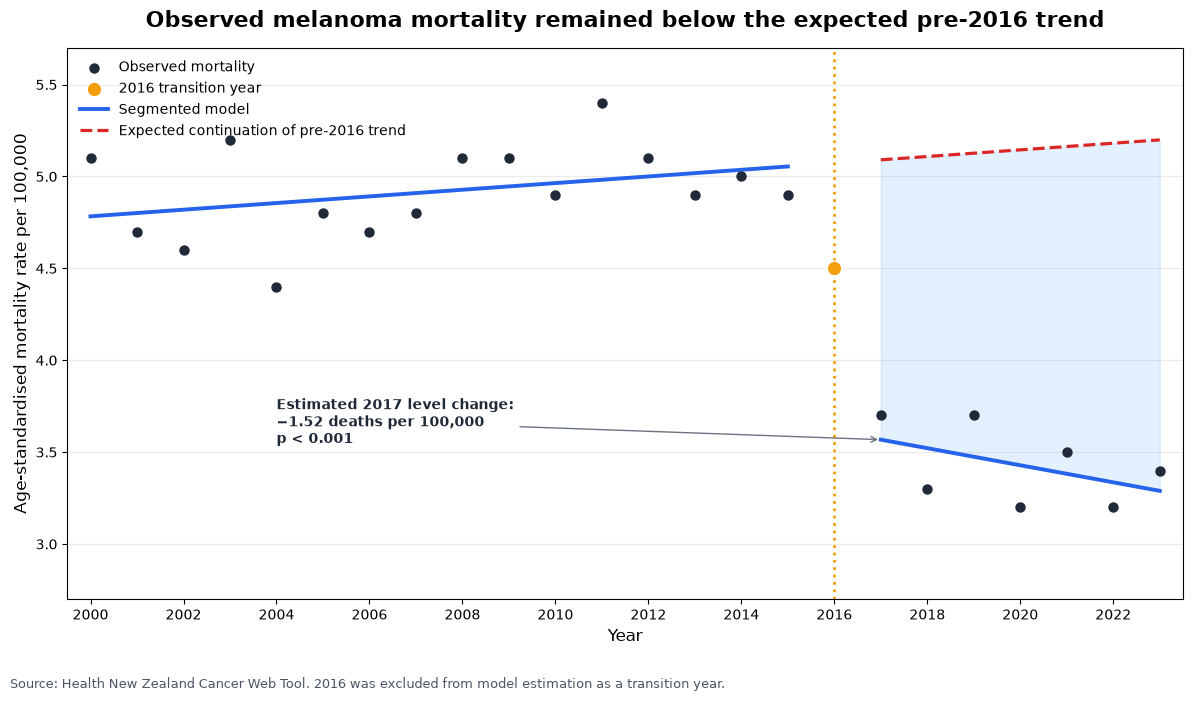

Figure saved: figures\Figure3_Segmented_Regression_and_Counterfactual.png


In [10]:
pre_years = np.arange(2000, 2016)
post_years = np.arange(2017, 2024)

pre_design = pd.DataFrame(
    {
        "const": 1.0,
        "time": pre_years - 2000,
        "post_introduction": 0,
        "time_after_introduction": 0,
    }
)

post_design = pd.DataFrame(
    {
        "const": 1.0,
        "time": post_years - 2000,
        "post_introduction": 1,
        "time_after_introduction": post_years - 2017,
    }
)

counterfactual_design = pd.DataFrame(
    {
        "const": 1.0,
        "time": post_years - 2000,
        "post_introduction": 0,
        "time_after_introduction": 0,
    }
)

pre_fitted = segmented_model.predict(pre_design)
post_fitted = segmented_model.predict(post_design)
counterfactual = segmented_model.predict(
    counterfactual_design
)

observed_all_sex = melanoma_df.loc[
    (melanoma_df["sex"] == "All sex")
    & (melanoma_df["year"] >= 2000)
].copy()

transition_point = observed_all_sex.loc[
    observed_all_sex["year"] == 2016
]

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    observed_all_sex["year"],
    observed_all_sex["asr"],
    color="#1F2937",
    s=42,
    label="Observed mortality",
    zorder=3,
)

ax.scatter(
    transition_point["year"],
    transition_point["asr"],
    color="#F59E0B",
    edgecolor="white",
    linewidth=1,
    s=110,
    label="2016 transition year",
    zorder=4,
)

ax.plot(
    pre_years,
    pre_fitted,
    color="#2563EB",
    linewidth=2.8,
    label="Segmented model",
)

ax.plot(
    post_years,
    post_fitted,
    color="#2563EB",
    linewidth=2.8,
)

ax.plot(
    post_years,
    counterfactual,
    color="#DC2626",
    linewidth=2.3,
    linestyle="--",
    label="Expected continuation of pre-2016 trend",
)

ax.fill_between(
    post_years,
    post_fitted,
    counterfactual,
    color="#93C5FD",
    alpha=0.25,
)

ax.axvline(
    2016,
    color="#F59E0B",
    linestyle=":",
    linewidth=2,
)

ax.annotate(
    "Estimated 2017 level change:\n−1.52 deaths per 100,000\np < 0.001",
    xy=(2017, post_fitted.iloc[0]),
    xytext=(2004, 3.55),
    fontsize=10,
    fontweight="bold",
    color="#1F2937",
    arrowprops={
        "arrowstyle": "->",
        "color": "#6B7280",
    },
)

ax.set_title(
    "Observed melanoma mortality remained below the expected pre-2016 trend",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel(
    "Age-standardised mortality rate per 100,000",
    fontsize=12,
)

ax.set_xlim(1999.5, 2023.5)
ax.set_ylim(2.7, 5.7)
ax.set_xticks(range(2000, 2024, 2))
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

fig.text(
    0.01,
    0.01,
    "Source: Health New Zealand Cancer Web Tool. "
    "2016 was excluded from model estimation as a transition year.",
    fontsize=9,
    color="#4B5563",
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

figure_path = figures_dir / (
    "Figure3_Segmented_Regression_and_Counterfactual.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved: {figure_path}")

### Interpretation of Figure 3

The counterfactual model projected that the mortality rate would remain above approximately 5 deaths per 100,000 if the pre-2016 trend continued. In contrast, observed post-introduction rates remained between approximately 3.2 and 3.7 deaths per 100,000.

The persistent separation between the fitted post-introduction trend and the counterfactual trend supports a sustained mortality reduction. This comparison represents a model-based counterfactual and should not be interpreted as definitive proof that treatment introduction alone caused the observed difference.

## 10. Sex-Stratified Segmented Regression

Separate segmented regression models were fitted for males and females to determine whether the post-2016 mortality change was consistent across sex groups. These subgroup analyses used the same 2000–2023 period, excluded 2016, and applied HAC standard errors with two lags.

In [11]:
def fit_sex_model(sex_group):
    sex_model_df = melanoma_df.loc[
        (melanoma_df["sex"] == sex_group)
        & (melanoma_df["year"] >= 2000)
        & (melanoma_df["year"] != 2016)
    ].copy()

    sex_model_df["time"] = (
        sex_model_df["year"] - 2000
    )

    sex_model_df["post_introduction"] = (
        sex_model_df["year"] >= 2017
    ).astype(int)

    sex_model_df["time_after_introduction"] = np.where(
        sex_model_df["year"] >= 2017,
        sex_model_df["year"] - 2017,
        0,
    )

    sex_x = sm.add_constant(
        sex_model_df[
            [
                "time",
                "post_introduction",
                "time_after_introduction",
            ]
        ]
    )

    sex_model = sm.OLS(
        sex_model_df["asr"],
        sex_x,
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 2},
    )

    confidence_intervals = sex_model.conf_int()

    post_slope_test = sex_model.t_test(
        [0, 1, 0, 1]
    )

    return {
        "sex": sex_group,
        "pre_period_slope": sex_model.params["time"],
        "pre_slope_p_value": sex_model.pvalues["time"],
        "level_change": sex_model.params[
            "post_introduction"
        ],
        "level_change_ci_lower":
            confidence_intervals.loc[
                "post_introduction", 0
            ],
        "level_change_ci_upper":
            confidence_intervals.loc[
                "post_introduction", 1
            ],
        "level_change_p_value": sex_model.pvalues[
            "post_introduction"
        ],
        "post_period_slope": np.asarray(
            post_slope_test.effect
        ).item(),
        "post_slope_p_value": np.asarray(
            post_slope_test.pvalue
        ).item(),
        "r_squared": sex_model.rsquared,
    }


sex_model_results = pd.DataFrame(
    [
        fit_sex_model("All sex"),
        fit_sex_model("Male"),
        fit_sex_model("Female"),
    ]
)

sex_model_results = sex_model_results.round(3)

display(sex_model_results)

,sex,pre_period_slope,pre_slope_p_value,level_change,level_change_ci_lower,level_change_ci_upper,level_change_p_value,post_period_slope,post_slope_p_value,r_squared
0,All sex,0.018,0.051,-1.523,-1.765,-1.281,0.0,-0.046,0.001,0.913
1,Male,0.041,0.017,-2.049,-2.405,-1.693,0.0,-0.093,0.001,0.845
2,Female,-0.011,0.268,-0.967,-1.193,-0.741,0.0,-0.025,0.027,0.882


### Interpretation of the Sex-Stratified Models

A significant post-introduction level reduction was observed in both males and females. The estimated reduction was larger in absolute terms among males (−2.049 deaths per 100,000; 95% CI: −2.405 to −1.693; p < 0.001) than females (−0.967; 95% CI: −1.193 to −0.741; p < 0.001).

Before 2016, male mortality was increasing significantly, whereas the female trend was relatively stable. After the transition, mortality declined significantly among both males and females.

The consistency of the direction of change supports the robustness of the overall finding. However, separate subgroup models do not formally establish that the magnitude of the change differed between males and females.

## 11. Model Diagnostics

Residual diagnostics were examined to assess model fit, residual distribution, heteroskedasticity, and remaining serial correlation. HAC standard errors were retained because annual mortality observations may be temporally correlated.

,diagnostic,statistic,p_value
0,Durbin–Watson,2.626,NaN
1,Jarque–Bera,0.395,0.821
2,Breusch–Pagan,3.133,0.372
3,Ljung–Box lag 1,3.514,0.061
4,Ljung–Box lag 2,4.564,0.102


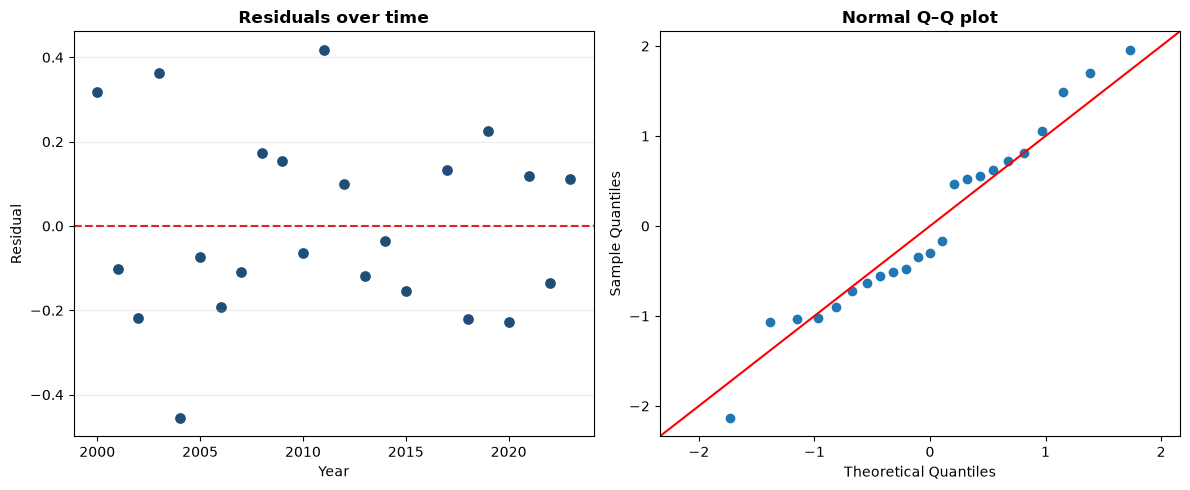

Figure saved: figures\Figure4_Segmented_Model_Diagnostics.png


In [12]:
model_residuals = segmented_model.resid

jarque_bera_result = sm.stats.jarque_bera(
    model_residuals
)

breusch_pagan_result = (
    sm.stats.diagnostic.het_breuschpagan(
        model_residuals,
        segmented_model.model.exog,
    )
)

ljung_box_result = sm.stats.acorr_ljungbox(
    model_residuals,
    lags=[1, 2],
    return_df=True,
)

diagnostic_results = pd.DataFrame(
    {
        "diagnostic": [
            "Durbin–Watson",
            "Jarque–Bera",
            "Breusch–Pagan",
            "Ljung–Box lag 1",
            "Ljung–Box lag 2",
        ],
        "statistic": [
            durbin_watson,
            jarque_bera_result[0],
            breusch_pagan_result[0],
            ljung_box_result.loc[1, "lb_stat"],
            ljung_box_result.loc[2, "lb_stat"],
        ],
        "p_value": [
            np.nan,
            jarque_bera_result[1],
            breusch_pagan_result[1],
            ljung_box_result.loc[1, "lb_pvalue"],
            ljung_box_result.loc[2, "lb_pvalue"],
        ],
    }
).round(3)

display(diagnostic_results)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

axes[0].scatter(
    model_df["year"],
    model_residuals,
    color="#1F4E79",
    s=45,
)

axes[0].axhline(
    0,
    color="#DC2626",
    linestyle="--",
    linewidth=1.5,
)

axes[0].set_title(
    "Residuals over time",
    fontweight="bold",
)

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Residual")
axes[0].grid(axis="y", alpha=0.25)
axes[0].grid(axis="x", visible=False)

sm.qqplot(
    model_residuals,
    line="45",
    fit=True,
    ax=axes[1],
)

axes[1].set_title(
    "Normal Q–Q plot",
    fontweight="bold",
)

plt.tight_layout()

figure_path = figures_dir / (
    "Figure4_Segmented_Model_Diagnostics.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved: {figure_path}")

### Interpretation of Model Diagnostics

The residuals showed no evidence of substantial non-normality (Jarque–Bera p = 0.821) or heteroskedasticity (Breusch–Pagan p = 0.372). The Ljung–Box tests were not statistically significant at lags one or two, although the lag-one result was borderline (p = 0.061).

The Durbin–Watson statistic of 2.626 suggested the possibility of some negative residual autocorrelation. The use of HAC standard errors was therefore retained to provide more reliable statistical inference. Overall, no major diagnostic problem was identified that would invalidate the primary model.

## 12. Export of Analysis Outputs

The cleaned dataset, descriptive summaries, regression results, sensitivity analyses, subgroup models, and diagnostic results were exported for reporting and reproducibility.

In [13]:
data_dir = Path("data")
tables_dir = Path("tables")

data_dir.mkdir(exist_ok=True)
tables_dir.mkdir(exist_ok=True)

cleaned_data_path = (
    data_dir
    / "NZ_Melanoma_Mortality_Cleaned_1954_2023.csv"
)

period_summary_path = (
    tables_dir
    / "Table1_Descriptive_Period_Comparison.csv"
)

primary_model_path = (
    tables_dir
    / "Table2_Primary_Segmented_Regression.csv"
)

sensitivity_path = (
    tables_dir
    / "Table3_Lag_Sensitivity_Analysis.csv"
)

sex_models_path = (
    tables_dir
    / "Table4_Sex_Stratified_Models.csv"
)

diagnostics_path = (
    tables_dir
    / "Table5_Model_Diagnostics.csv"
)

model_text_path = (
    tables_dir
    / "Primary_Segmented_Regression_Full_Summary.txt"
)

melanoma_df.to_csv(
    cleaned_data_path,
    index=False,
)

period_summary.to_csv(
    period_summary_path,
    index=False,
)

model_results.rename_axis(
    "model_term"
).reset_index().to_csv(
    primary_model_path,
    index=False,
)

sensitivity_results.to_csv(
    sensitivity_path,
    index=False,
)

sex_model_results.to_csv(
    sex_models_path,
    index=False,
)

diagnostic_results.to_csv(
    diagnostics_path,
    index=False,
)

model_text_path.write_text(
    segmented_model.summary().as_text(),
    encoding="utf-8",
)

saved_outputs = [
    cleaned_data_path,
    period_summary_path,
    primary_model_path,
    sensitivity_path,
    sex_models_path,
    diagnostics_path,
    model_text_path,
]

print("Saved analysis outputs:\n")

for output_path in saved_outputs:
    print(f"- {output_path}")

Saved analysis outputs:

- data\NZ_Melanoma_Mortality_Cleaned_1954_2023.csv
- tables\Table1_Descriptive_Period_Comparison.csv
- tables\Table2_Primary_Segmented_Regression.csv
- tables\Table3_Lag_Sensitivity_Analysis.csv
- tables\Table4_Sex_Stratified_Models.csv
- tables\Table5_Model_Diagnostics.csv
- tables\Primary_Segmented_Regression_Full_Summary.txt


## 13. Key Findings

1. The mean all-sex age-standardised melanoma mortality rate was 30.2% lower during 2017–2020 and 32.3% lower during 2021–2023 compared with 2012–2015.

2. The primary segmented regression estimated a reduction of 1.523 deaths per 100,000 at the beginning of the post-introduction period in 2017 (95% CI: −1.765 to −1.281; p < 0.001).

3. The estimated post-introduction trend remained negative at −0.046 deaths per 100,000 per year (p = 0.001).

4. Sensitivity analyses that allowed the post-introduction period to begin in 2017, 2018, or 2019 consistently identified a significant level reduction of approximately 1.5 to 1.7 deaths per 100,000.

5. Significant reductions were observed among both males and females. The absolute reduction was larger among males, who had substantially higher baseline mortality rates.

6. Observed mortality remained below the modelled continuation of the pre-2016 trend through 2023.

## 14. Interpretation for Decision-Makers

The findings provide consistent population-level evidence that the introduction of modern systemic therapies in New Zealand during 2016 coincided with a large and sustained reduction in melanoma mortality.

The reduction was not limited to a single year or a short temporary period. It persisted across the available post-introduction years, remained evident under alternative lag assumptions, and was observed among both males and females.

These results support the presence of an important change in melanoma outcomes following the introduction of effective systemic treatments. However, the analysis cannot attribute the entire mortality reduction to treatment funding alone.

## 15. Limitations

- This was an ecological time-series analysis based on national annual mortality data.
- Individual treatment exposure, disease stage, tumour characteristics, treatment response, and survival time were unavailable.
- Public funding dates do not necessarily represent immediate or uniform treatment uptake.
- Changes in prevention, early detection, diagnosis, staging, surgery, referral pathways, and supportive care may also have influenced mortality.
- Only seven post-introduction years were available, and the 2022 and 2023 data were provisional and preliminary.
- The counterfactual trend depends on the assumption that the pre-2016 linear trend would otherwise have continued.
- Separate male and female models do not constitute a formal statistical test of interaction between sex and treatment period.
- The findings demonstrate temporal association and should not be interpreted as definitive evidence of causation.

## 16. Conclusion

The introduction of modern systemic therapies for melanoma in New Zealand during 2016 was associated with a substantial and sustained reduction in age-standardised melanoma mortality.

The estimated decline remained robust across alternative lag assumptions and was observed among both males and females. The available evidence therefore supports a sustained rather than temporary population-level change.

Further research using patient-level treatment, stage, survival, and medicine-utilisation data would be required to quantify how much of the decline was directly attributable to specific therapies.

## References

1. [Health New Zealand – Cancer Web Tool](https://www.healthnz.govt.nz/about-us/health-data/data-sets-and-collections/cancer-data-and-statistics/cancer-web-tool)

2. [Health New Zealand – Interactive Cancer Web Tool](https://tewhatuora.shinyapps.io/cancer-web-tool/)

3. [PHARMAC – New Zealand Pharmaceutical Management Agency](https://pharmac.govt.nz/)

4. [New Zealand Pharmaceutical Schedule](https://schedule.pharmac.govt.nz/)